## Laboratório 4 – Treinamento e Testes

### Parte 1 – Importação de Bibliotecas e Leitura de Dataset

#### Importação de Bibliotecas

In [1]:
import pandas as pd
from sklearn import datasets, linear_model
from matplotlib import pyplot as plt
import numpy as np
from sklearn.model_selection import KFold # Para estratégia de Cross-Validadion (K-Folds)
from sklearn.model_selection import train_test_split # Para estratégia Train/Test Split


#### Leitura de Dataset - Diabetes, do SKLearn

In [2]:
columns = "age sex bmi bp tc ldl hdl tch ltg glu".split() # Declara os nomes das colunas
diabetes = datasets.load_diabetes() # Carrega o dataset diabetes de sklearn
df = pd.DataFrame(diabetes.data, columns=columns) # Carrega o dataset como um data frame
y = diabetes.target # define a variavel target variable (varivavel dependente, no modelo de regressão)


### Parte 2 – Train/Test Split

#### Treinamento e Testes - Estratégia: Train/Test Split (20% para Testes)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2)
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)


(353, 10) (353,)
(89, 10) (89,)


### Parte 3 – Modelo de Regressão Linear

#### Construção e Aplicação do Modelo: Regressão Linear

In [4]:
lm = linear_model.LinearRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)
predictions[0:5]


array([213.0856105 , 186.67434345, 122.29429583,  65.0525928 ,
       184.63762968])

#### Exibição do Modelo: Scatter Plot

Text(0, 0.5, 'Predictions')

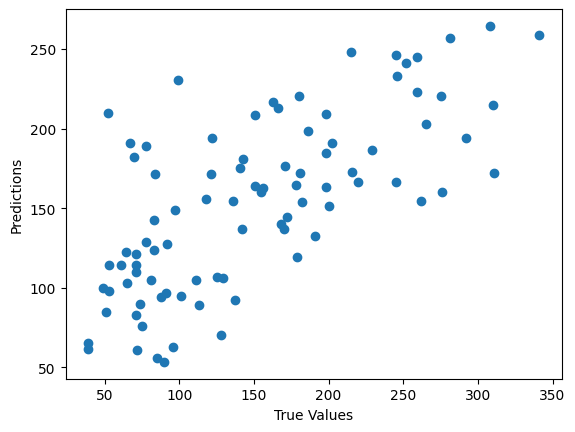

In [5]:
plt.scatter(y_test, predictions)
plt.xlabel("True Values")
plt.ylabel("Predictions")


#### Exibição de percentual de acurácia

In [6]:
print ("Score:", model.score(X_test, y_test))

Score: 0.4893715539973079


### Desafio 1:

#### Inclusão da feature “target” no dataframe assim como os valores previstos pelo modelo, de forma a comparar

In [ ]:
lm = linear_model.LinearRegression()
modelTest = lm.fit(X_test, y_test)
predictionsTest  = modelTest.predict(X_test)
modelTrain = lm.fit(X_train, y_train)
predictionsTrain = modelTrain.predict(X_train)

df['target'] = diabetes.target
df_train = pd.DataFrame({
    'y_real': y_train,
    'prediction': predictionsTrain,
    'dataset': 'train'  # marcador para identificar
})

df_test = pd.DataFrame({
    'y_real': y_test,
    'prediction': predictionsTest,
    'dataset': 'test'  # marcador para identificar
})

df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all


### Desafio 2:

#### Experimente outros percentuais de splitting e veja como fica a acurácia? Por que melhora (ou piora)?

### Parte 4 – Cross-Validation (K-Folds)

In [ ]:
# Treinamento e Testes - Estratégia: Cross Validation (2 folds)

X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]]) # Cria um array como dataset exemplo
y = np.array([1, 2, 3, 4]) # Cria um outro array como dataset exemplo
kf = KFold(n_splits=2) # Define a separação (split) em 2 folds (k=2)

kf.get_n_splits(X) # Retorna o numero de iterações de separação (splitting) do cross-validator
print(kf)

KFold(n_splits=2, random_state=None, shuffle=False)

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index, "TEST:", test_index) # Linhas do array usadas para TRAIN e TEST


### Desafio 3:

#### Experimente outras quantidades de splits para ver como o cross validator trabalha.